In [3]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
# from FloorAffinityBuilder import SpectralClusteringAnalyzer


In [20]:
graphs = pickle.load(open("output/graphs.pkl", "rb"))

In [21]:
graphs

[{'filename': '2612.png',
  'rooms': [{'type': 'common_room',
    'polygon': <POLYGON ((157 59, 157 109, 202 109, 202 59, 157 59))>,
    'area': 2250.0,
    'centroid': (179.5, 84.0)},
   {'type': 'master_room',
    'polygon': <POLYGON ((105 115, 105 124, 104 125, 76 125, 76 177, 120 177, 120 115, 105 ...>,
    'area': 2438.5,
    'centroid': (98.8933087280432, 149.0876905201285)},
   {'type': 'living_room',
    'polygon': <POLYGON ((105 59, 105 72, 104 73, 86 73, 86 89, 104 89, 105 90, 105 109, 12...>,
    'area': 6042.0,
    'centroid': (139.9478925300673, 118.26762661370407)},
   {'type': 'balcony',
    'polygon': <POLYGON ((126 183, 126 197, 179 197, 179 183, 126 183))>,
    'area': 742.0,
    'centroid': (152.5, 190.0)},
   {'type': 'bathroom',
    'polygon': <POLYGON ((54 59, 54 89, 80 89, 80 59, 54 59))>,
    'area': 780.0,
    'centroid': (67.0, 74.0)},
   {'type': 'kitchen',
    'polygon': <POLYGON ((54 95, 54 119, 99 119, 99 95, 54 95))>,
    'area': 1080.0,
    'centroid': (

In [4]:
nnary_df = pd.read_csv("./output/nnary_features_enhanced.csv").set_index("filename")
nnary_df = nnary_df.fillna(0)

nnary_df = nnary_df.loc[:, ~(nnary_df == 0).all()]
nnary_sans78_df = nnary_df.loc[:, ~nnary_df.columns.str.contains(r'7|8')]

In [5]:
feature_cols = list(nnary_sans78_df.columns)


In [6]:
feature_cols

['uni_1_aspect',
 'uni_2_aspect',
 'uni_3_aspect',
 'uni_4_aspect',
 'uni_5_aspect',
 'uni_6_aspect',
 'uni_1_count',
 'uni_1_total_area',
 'uni_1_avg_x',
 'uni_1_avg_y',
 'uni_2_count',
 'uni_2_total_area',
 'uni_2_avg_x',
 'uni_2_avg_y',
 'uni_3_count',
 'uni_3_total_area',
 'uni_3_avg_x',
 'uni_3_avg_y',
 'uni_4_count',
 'uni_4_total_area',
 'uni_4_avg_x',
 'uni_4_avg_y',
 'uni_5_count',
 'uni_5_total_area',
 'uni_5_avg_x',
 'uni_5_avg_y',
 'uni_6_count',
 'uni_6_total_area',
 'uni_6_avg_x',
 'uni_6_avg_y',
 'bi_1_2_count',
 'bi_1_2_area_ratio',
 'bi_1_2_avg_x',
 'bi_1_2_avg_y',
 'bi_1_3_count',
 'bi_1_3_area_ratio',
 'bi_1_3_avg_x',
 'bi_1_3_avg_y',
 'bi_1_4_count',
 'bi_1_4_area_ratio',
 'bi_1_4_avg_x',
 'bi_1_4_avg_y',
 'bi_1_5_count',
 'bi_1_5_area_ratio',
 'bi_1_5_avg_x',
 'bi_1_5_avg_y',
 'bi_1_6_count',
 'bi_1_6_area_ratio',
 'bi_1_6_avg_x',
 'bi_1_6_avg_y',
 'bi_2_3_count',
 'bi_2_3_area_ratio',
 'bi_2_3_avg_x',
 'bi_2_3_avg_y',
 'bi_2_4_count',
 'bi_2_4_area_ratio',
 'bi_2_

In [14]:
X = nnary_sans78_df[:5000].values
scaler = StandardScaler()
X = np.nan_to_num(X, nan=0.0)
X_scaled = scaler.fit_transform(X)

In [15]:
analyzer = SpectralClusteringAnalyzer(X_scaled, feature_cols)

Running K-means clustering...

Running Spectral clustering with rbf affinity...


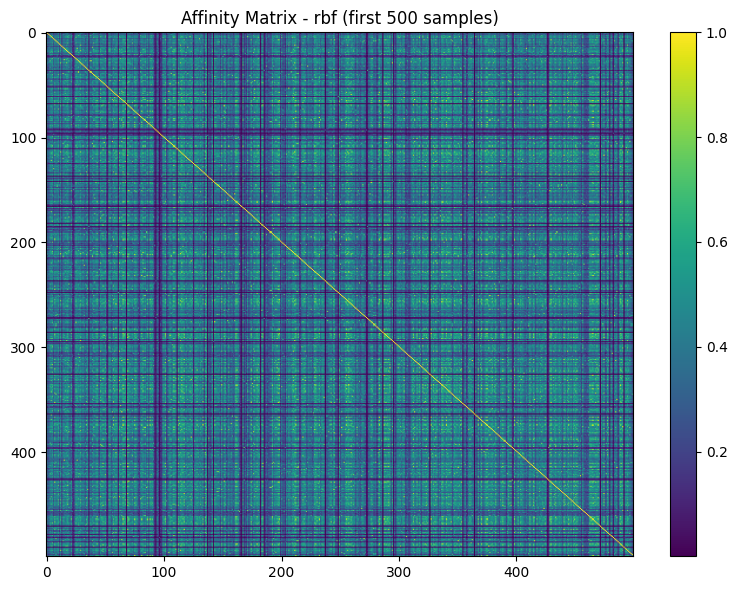


Running Spectral clustering with weighted affinity...


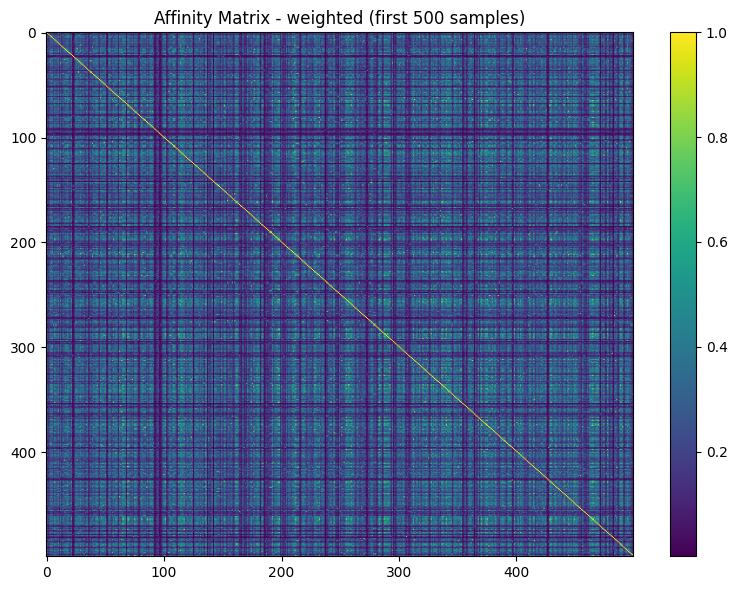


Running Spectral clustering with adjacency affinity...


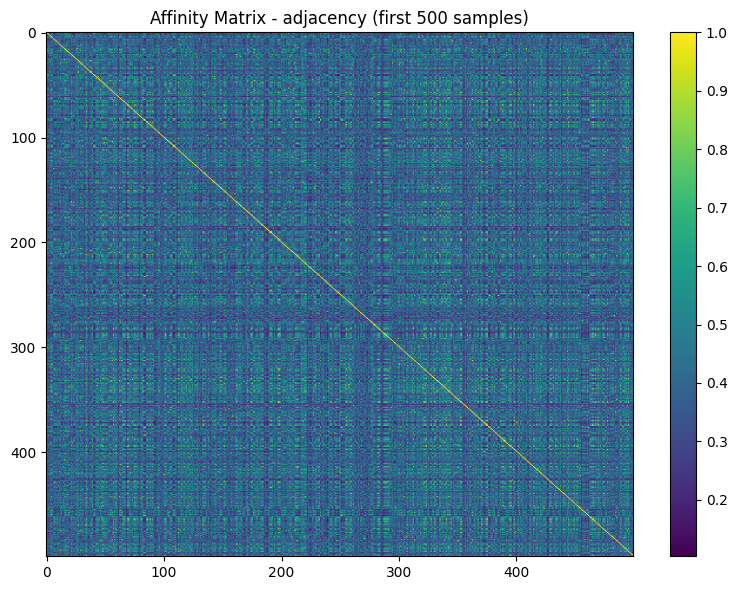


Running Spectral clustering with spatial affinity...


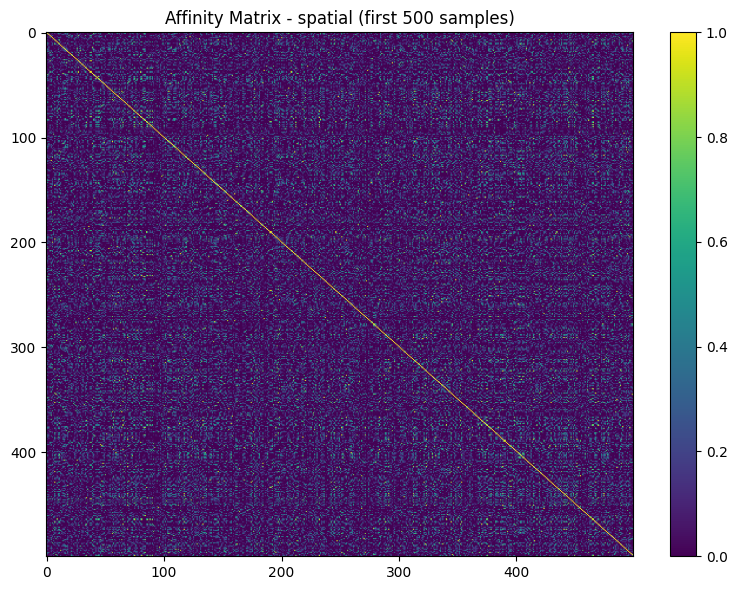


Running Spectral clustering with hybrid affinity...


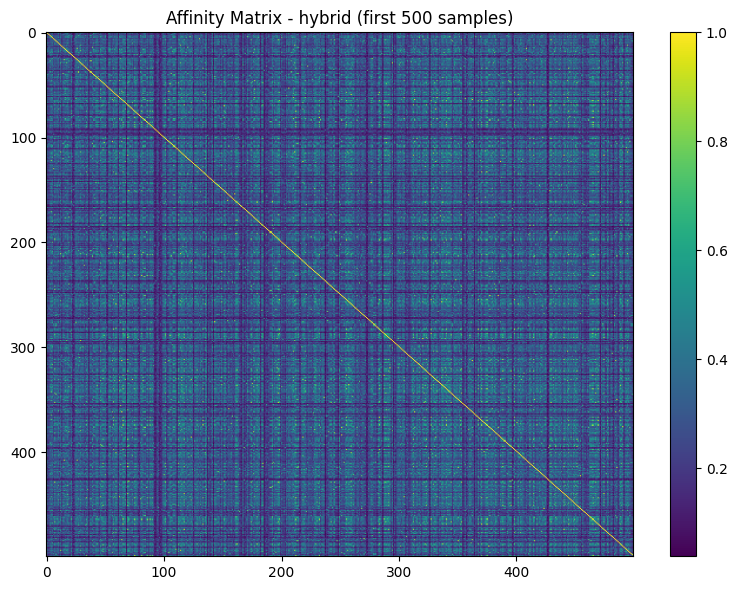

In [16]:
results =  analyzer.compare_clustering_methods(n_clusters=16)

In [18]:
# Print comparison table
comparison_df = pd.DataFrame([
    {
        'Method': method,
        'Silhouette Score': result.get('silhouette', 'N/A'),
        'Calinski-Harabasz': result.get('calinski_harabasz', 'N/A')
    }
    for method, result in results.items()
    if 'error' not in result
])

print("\nClustering Performance Comparison:")
print(comparison_df.round(3))
print("\n=== Analyzing Spectral Clustering Stability ===")
stability, _ = analyzer.analyze_cluster_stability()


Clustering Performance Comparison:
               Method  Silhouette Score  Calinski-Harabasz
0              kmeans             0.051            148.058
1        spectral_rbf             0.041            103.614
2   spectral_weighted             0.033            110.363
3  spectral_adjacency             0.020            100.197
4    spectral_spatial             0.019            102.564
5     spectral_hybrid             0.036            118.850

=== Analyzing Spectral Clustering Stability ===
Analyzing stability over 10 iterations...
Average pairwise stability: 0.106


In [ ]:
tuning_results = analyzer.parameter_tuning(n_clusters_range=range(8, 23))

/home/airlay88/planscape/venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
best_method = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Method']
best_labels = results[best_method]['labels']

print(f"\nBest performing method: {best_method}")